In [ ]:
# ============================================================
# CELL 1 : Install Required Libraries
# ============================================================

!pip -q install openai pandas tqdm

In [ ]:
# ============================================================
# CELL 2 : Import Required Libraries
# ============================================================

import json
import pandas as pd
from tqdm import tqdm

from openai import OpenAI

print("✅ Libraries Imported Successfully")

✅ Libraries Imported Successfully


In [ ]:
# ============================================================
# CELL 3 : Configure OpenRouter
# ============================================================

# Replace with your OpenRouter API Key
OPENROUTER_API_KEY = "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"

MODEL_NAME = "deepseek/deepseek-chat"

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY
)

print("="*60)
print("✅ OpenRouter Connected Successfully")
print("Model :", MODEL_NAME)
print("="*60)

✅ OpenRouter Connected Successfully
Model : deepseek/deepseek-chat


In [ ]:
# ============================================================
# CELL 4 : LLM Helper Function
# ============================================================

def chat_with_llm(system_prompt,
                  user_prompt,
                  temperature=0,
                  max_tokens=500):

    try:

        response = client.chat.completions.create(

            model=MODEL_NAME,

            messages=[
                {
                    "role":"system",
                    "content":system_prompt
                },
                {
                    "role":"user",
                    "content":user_prompt
                }
            ],

            temperature=temperature,
            max_tokens=max_tokens

        )

        return response.choices[0].message.content.strip()

    except Exception as e:

        print("LLM Error :",e)

        return None

In [ ]:
system = "You are a helpful AI."

user = "Reply with only SUCCESS"

print(chat_with_llm(system,user))

SUCCESS


In [ ]:
# ============================================================
# CELL 5 : Load Resume Evaluation Results
# ============================================================

import json

# Path to your JSON file
JSON_FILE = "/content/complete_pipeline_results.json"

with open(JSON_FILE, "r", encoding="utf-8") as f:
    resumes = json.load(f)

print("="*70)
print(f"✅ Successfully Loaded {len(resumes)} Resume Records")
print("="*70)

# Preview first resume
sample = resumes[0]

print("\nSample Resume Information")
print("-"*40)

print("Domain      :", sample["domain"])
print("Job Level   :", sample["target_job"])

print("\nResume Scores")

print("Education      :", sample["resume_evaluator"]["education_score"])
print("Skills         :", sample["resume_evaluator"]["skills_score"])
print("Experience     :", sample["resume_evaluator"]["experience_score"])
print("Certification  :", sample["resume_evaluator"]["certification_score"])
print("Domain Score   :", sample["resume_evaluator"]["domain_score"])
print("Overall Score  :", sample["resume_evaluator"]["overall_score"])

✅ Successfully Loaded 302 Resume Records

Sample Resume Information
----------------------------------------
Domain      : Banking
Job Level   : Entry-level

Resume Scores
Education      : 8.0
Skills         : 7.0
Experience     : 8.0
Certification  : 0
Domain Score   : 8.0
Overall Score  : 7.0


In [ ]:
# ============================================================
# CELL 6 : Dynamic Weight Generator
# ============================================================

weight_cache = {}

def get_dynamic_weights(domain, job_level):

    cache_key = f"{domain}_{job_level}"

    if cache_key in weight_cache:
        return weight_cache[cache_key]

    system_prompt = """
You are an expert HR recruiter.

For the given Job Domain and Job Level,
assign importance weights for:

1. Education
2. Skills
3. Experience
4. Certification
5. Domain Knowledge

Rules:

- Return ONLY JSON.
- No explanation.
- No markdown.
- Weights must sum to exactly 1.

Example:

{
"education":0.20,
"skills":0.30,
"experience":0.25,
"certification":0.10,
"domain":0.15
}
"""

    user_prompt = f"""
Job Domain : {domain}

Job Level : {job_level}
"""

    response = chat_with_llm(
        system_prompt,
        user_prompt,
        temperature=0
    )

    try:

        cleaned = response.strip()

        cleaned = cleaned.replace("```json","")
        cleaned = cleaned.replace("```","")
        cleaned = cleaned.strip()

        weights = json.loads(cleaned)

    except Exception as e:

        print("JSON Parsing Error:", e)
        print("LLM Response:", response)

        weights = {
            "education":0.20,
            "skills":0.30,
            "experience":0.25,
            "certification":0.10,
            "domain":0.15
        }

    # -------- Standardize Keys -------- #

    standardized = {
        "education":0,
        "skills":0,
        "experience":0,
        "certification":0,
        "domain":0
    }

    for key,value in weights.items():

        k = key.lower().replace(" ","_")

        if "education" in k:
            standardized["education"] = value

        elif "skill" in k:
            standardized["skills"] = value

        elif "experience" in k:
            standardized["experience"] = value

        elif "cert" in k:
            standardized["certification"] = value

        elif "domain" in k:
            standardized["domain"] = value

    # -------- Normalize -------- #

    total = sum(standardized.values())

    standardized = {
        k: round(v/total,4)
        for k,v in standardized.items()
    }

    weight_cache[cache_key] = standardized

    return standardized

In [ ]:
weights = get_dynamic_weights(
    resumes[0]["domain"],
    resumes[0]["target_job"]
)

print(weights)

{'education': 0.3, 'skills': 0.25, 'experience': 0.2, 'certification': 0.15, 'domain': 0.1}


In [ ]:
# ============================================================
# CELL 7 : Calculate Dynamic Resume Scores
# ============================================================

print("="*70)
print("Calculating Dynamic Resume Scores...")
print("="*70)

for resume in tqdm(resumes):

    # -----------------------------
    # Get Dynamic Weights
    # -----------------------------
    weights = get_dynamic_weights(
        resume["domain"],
        resume["target_job"]
    )

    # -----------------------------
    # Resume Scores
    # -----------------------------
    scores = resume["resume_evaluator"]

    education = scores["education_score"]
    skills = scores["skills_score"]
    experience = scores["experience_score"]
    certification = scores["certification_score"]
    domain = scores["domain_score"]

    # -----------------------------
    # Dynamic Weighted Score
    # -----------------------------
    dynamic_score = (
        education * weights["education"] +
        skills * weights["skills"] +
        experience * weights["experience"] +
        certification * weights["certification"] +
        domain * weights["domain"]
    )

    dynamic_score = round(dynamic_score, 2)

    # -----------------------------
    # Store Results
    # -----------------------------
    resume["dynamic_weights"] = weights
    resume["dynamic_final_score"] = dynamic_score

print("\n✅ Dynamic Score Calculation Completed!")

Calculating Dynamic Resume Scores...


100%|██████████| 302/302 [00:30<00:00,  9.85it/s]


✅ Dynamic Score Calculation Completed!


In [ ]:
# ============================================================
# CELL 8 : Save Updated JSON Results
# ============================================================

import json

OUTPUT_JSON = "dynamic_pipeline_results.json"

with open(OUTPUT_JSON, "w", encoding="utf-8") as f:
    json.dump(resumes, f, indent=4)

print("="*60)
print("✅ Updated JSON Saved Successfully")
print("Location :", OUTPUT_JSON)
print("="*60)

✅ Updated JSON Saved Successfully
Location : dynamic_pipeline_results.json


In [ ]:
# ============================================================
# CELL 9 : Export CSV Results
# ============================================================

rows = []

for resume in resumes:

    scores = resume["resume_evaluator"]

    rows.append({

        "Domain": resume["domain"],

        "Job_Level": resume["target_job"],

        "Education_Score": scores["education_score"],

        "Skills_Score": scores["skills_score"],

        "Experience_Score": scores["experience_score"],

        "Certification_Score": scores["certification_score"],

        "Domain_Score": scores["domain_score"],

        "Overall_Score": scores["overall_score"],

        "Dynamic_Final_Score": resume["dynamic_final_score"],

        "Education_Weight": resume["dynamic_weights"]["education"],

        "Skills_Weight": resume["dynamic_weights"]["skills"],

        "Experience_Weight": resume["dynamic_weights"]["experience"],

        "Certification_Weight": resume["dynamic_weights"]["certification"],

        "Domain_Weight": resume["dynamic_weights"]["domain"]

    })

df = pd.DataFrame(rows)

OUTPUT_CSV = "dynamic_resume_scores.csv"

df.to_csv(OUTPUT_CSV, index=False)

print("="*60)
print("✅ CSV Saved Successfully")
print("Location :", OUTPUT_CSV)
print("="*60)

print("\nPreview\n")

display(df.head())

✅ CSV Saved Successfully
Location : dynamic_resume_scores.csv

Preview



,Domain,Job_Level,Education_Score,Skills_Score,Experience_Score,Certification_Score,Domain_Score,Overall_Score,Dynamic_Final_Score,Education_Weight,Skills_Weight,Experience_Weight,Certification_Weight,Domain_Weight
0,Banking,Entry-level,8.0,7.0,8.0,0.0,8.0,7.0,6.55,0.30,0.25,0.20,0.15,0.10
1,Banking,Mid-level,4.0,8.0,8.0,0.0,8.0,6.0,6.00,0.20,0.30,0.25,0.15,0.10
2,Banking,Mid-level,9.0,9.0,8.0,5.0,8.0,8.0,8.05,0.20,0.30,0.25,0.15,0.10
3,Banking,Senior-level,8.0,7.0,7.0,0.0,7.0,7.0,6.45,0.15,0.25,0.35,0.10,0.15
4,Banking,Entry-level,8.0,8.0,7.0,0.0,7.0,7.0,6.50,0.30,0.25,0.20,0.15,0.10


In [ ]:
# ============================================================
# CELL 10 : Final Verification
# ============================================================

print("="*70)
print("Dynamic Weight Allocation Completed Successfully")
print("="*70)

print(f"Total Resumes : {len(resumes)}")

print("\nSample Resume\n")

sample = resumes[0]

print("Domain :", sample["domain"])
print("Job Level :", sample["target_job"])

print("\nDynamic Weights")

for k, v in sample["dynamic_weights"].items():
    print(f"{k:15s}: {v}")

print("\nDynamic Final Score :", sample["dynamic_final_score"])

print("\nGenerated Files")

print("1. dynamic_pipeline_results.json")
print("2. dynamic_resume_scores.csv")

Dynamic Weight Allocation Completed Successfully
Total Resumes : 302

Sample Resume

Domain : Banking
Job Level : Entry-level

Dynamic Weights
education      : 0.3
skills         : 0.25
experience     : 0.2
certification  : 0.15
domain         : 0.1

Dynamic Final Score : 6.55

Generated Files
1. dynamic_pipeline_results.json
2. dynamic_resume_scores.csv


In [ ]:
# ============================================================
# CELL 11 : Calculate Metrics for Overall Weighted Score
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr, spearmanr

# -----------------------------
# Step 1: Extract Ground Truth (Avg of Annotator-1 and Annotator-2, multiplied by 10)
# -----------------------------

# Extract ground truth from JSON data (already normalized to 0-1 scale)
# Multiply by 10 to normalize to 0-10 scale
ground_truth = np.array([resume["ground_truth_score"] for resume in resumes]) * 10

# Extract overall weighted scores (dynamic_final_score from JSON)
# These are already on a 0-10 scale
overall_weighted_scores = np.array([resume["dynamic_final_score"] for resume in resumes])

print(f"\n📊 Data Summary:")
print(f"Total samples: {len(ground_truth)}")
print(f"Ground Truth range: {ground_truth.min():.2f} - {ground_truth.max():.2f}")
print(f"Overall Weighted Score range: {overall_weighted_scores.min():.2f} - {overall_weighted_scores.max():.2f}")

# -----------------------------
# Step 2: Calculate All Metrics
# -----------------------------

def calculate_all_metrics(actual, predicted):
    """
    Calculate: PC20, SC20, PC15, SC15, PC10, SC10, MAE, RMSE, R^2

    PC = Pearson Correlation at threshold (20%, 15%, 10%)
    SC = Spearman Correlation at threshold (20%, 15%, 10%)
    """
    n = len(actual)

    # ---------- PC20 and SC20: Correlation for samples within 20% ----------
    mask_20 = np.abs((actual - predicted) / np.where(actual == 0, 1e-10, actual)) * 100 <= 20
    if np.sum(mask_20) >= 3:  # Need at least 3 samples for correlation
        pc20 = pearsonr(actual[mask_20], predicted[mask_20])[0]
        sc20 = spearmanr(actual[mask_20], predicted[mask_20])[0]
    else:
        pc20 = np.nan
        sc20 = np.nan

    # ---------- PC15 and SC15: Correlation for samples within 15% ----------
    mask_15 = np.abs((actual - predicted) / np.where(actual == 0, 1e-10, actual)) * 100 <= 15
    if np.sum(mask_15) >= 3:
        pc15 = pearsonr(actual[mask_15], predicted[mask_15])[0]
        sc15 = spearmanr(actual[mask_15], predicted[mask_15])[0]
    else:
        pc15 = np.nan
        sc15 = np.nan

    # ---------- PC10 and SC10: Correlation for samples within 10% ----------
    mask_10 = np.abs((actual - predicted) / np.where(actual == 0, 1e-10, actual)) * 100 <= 10
    if np.sum(mask_10) >= 3:
        pc10 = pearsonr(actual[mask_10], predicted[mask_10])[0]
        sc10 = spearmanr(actual[mask_10], predicted[mask_10])[0]
    else:
        pc10 = np.nan
        sc10 = np.nan

    # ---------- MAE, RMSE, R^2 ----------
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted)

    # Count of samples in each threshold
    count_20 = np.sum(mask_20)
    count_15 = np.sum(mask_15)
    count_10 = np.sum(mask_10)

    return {
        "PC20": pc20,
        "SC20": sc20,
        "PC15": pc15,
        "SC15": sc15,
        "PC10": pc10,
        "SC10": sc10,
        "Count_20": count_20,
        "Count_15": count_15,
        "Count_10": count_10,
        "MAE": mae,
        "RMSE": rmse,
        "R^2": r2
    }

# Calculate metrics
metrics = calculate_all_metrics(ground_truth, overall_weighted_scores)

# -----------------------------
# Step 3: Display Results
# -----------------------------

print("\n" + "="*70)
print("METRICS RESULTS: OVERALL WEIGHTED SCORE vs GROUND TRUTH")
print("="*70)

print(f"\n{'Metric':<15} {'Value':<15} {'Description':<35}")
print("-"*70)

# PC20
count_20 = metrics['Count_20']
pc20_val = metrics['PC20']
print(f"{'PC20':<15} {pc20_val:>6.4f}     Pearson Correlation (within 20%, n={count_20})")

# SC20
sc20_val = metrics['SC20']
print(f"{'SC20':<15} {sc20_val:>6.4f}     Spearman Correlation (within 20%, n={count_20})")

# PC15
count_15 = metrics['Count_15']
pc15_val = metrics['PC15']
print(f"{'PC15':<15} {pc15_val:>6.4f}     Pearson Correlation (within 15%, n={count_15})")

# SC15
sc15_val = metrics['SC15']
print(f"{'SC15':<15} {sc15_val:>6.4f}     Spearman Correlation (within 15%, n={count_15})")

# PC10
count_10 = metrics['Count_10']
pc10_val = metrics['PC10']
print(f"{'PC10':<15} {pc10_val:>6.4f}     Pearson Correlation (within 10%, n={count_10})")

# SC10
sc10_val = metrics['SC10']
print(f"{'SC10':<15} {sc10_val:>6.4f}     Spearman Correlation (within 10%, n={count_10})")

# MAE
print(f"{'MAE':<15} {metrics['MAE']:>6.4f}     Mean Absolute Error")

# RMSE
print(f"{'RMSE':<15} {metrics['RMSE']:>6.4f}     Root Mean Squared Error")

# R^2
print(f"{'R^2':<15} {metrics['R^2']:>6.4f}     Coefficient of Determination")

print("\n" + "="*70)

# Also show full correlation (all data)
print("\n📊 FULL CORRELATION (All Data):")
pearson_all, p_pearson = pearsonr(ground_truth, overall_weighted_scores)
spearman_all, p_spearman = spearmanr(ground_truth, overall_weighted_scores)
print(f"  Pearson Correlation (all data):  {pearson_all:.4f}  (p-value: {p_pearson:.6f})")
print(f"  Spearman Correlation (all data): {spearman_all:.4f}  (p-value: {p_spearman:.6f})")

# -----------------------------
# Step 4: Create Summary DataFrame and Save
# -----------------------------

results_df = pd.DataFrame({
    'Metric': ['PC20', 'SC20', 'PC15', 'SC15', 'PC10', 'SC10', 'MAE', 'RMSE', 'R^2'],
    'Value': [
        f"{metrics['PC20']:.4f}",
        f"{metrics['SC20']:.4f}",
        f"{metrics['PC15']:.4f}",
        f"{metrics['SC15']:.4f}",
        f"{metrics['PC10']:.4f}",
        f"{metrics['SC10']:.4f}",
        f"{metrics['MAE']:.4f}",
        f"{metrics['RMSE']:.4f}",
        f"{metrics['R^2']:.4f}"
    ],
    'Description': [
        f"Pearson Corr (within 20%, n={metrics['Count_20']})",
        f"Spearman Corr (within 20%, n={metrics['Count_20']})",
        f"Pearson Corr (within 15%, n={metrics['Count_15']})",
        f"Spearman Corr (within 15%, n={metrics['Count_15']})",
        f"Pearson Corr (within 10%, n={metrics['Count_10']})",
        f"Spearman Corr (within 10%, n={metrics['Count_10']})",
        "Mean Absolute Error",
        "Root Mean Squared Error",
        "Coefficient of Determination"
    ]
})

# Save to CSV
results_df.to_csv("metrics_results.csv", index=False)
print("\n✅ Results saved to 'metrics_results.csv'")

# Display the DataFrame
print("\n📊 Summary Table:")
print(results_df.to_string(index=False))




📊 Data Summary:
Total samples: 302
Ground Truth range: 0.40 - 9.65
Overall Weighted Score range: 0.00 - 9.85

METRICS RESULTS: OVERALL WEIGHTED SCORE vs GROUND TRUTH

Metric          Value           Description                        
----------------------------------------------------------------------
PC20            0.7035     Pearson Correlation (within 20%, n=226)
SC20            0.6626     Spearman Correlation (within 20%, n=226)
PC15            0.8003     Pearson Correlation (within 15%, n=171)
SC15            0.7436     Spearman Correlation (within 15%, n=171)
PC10            0.9042     Pearson Correlation (within 10%, n=106)
SC10            0.8756     Spearman Correlation (within 10%, n=106)
MAE             1.2421     Mean Absolute Error
RMSE            1.5898     Root Mean Squared Error
R^2             0.2855     Coefficient of Determination


📊 FULL CORRELATION (All Data):
  Pearson Correlation (all data):  0.5859  (p-value: 0.000000)
  Spearman Correlation (all data): 0.6

In [4]:
import pandas as pd
import json

# -------------------------------
# Load CareerCorpus Dataset
# -------------------------------
career_df = pd.read_excel("/content/CareerCorpus.xlsx")

# -------------------------------
# Load Dynamic Weight JSON
# -------------------------------
with open("/content/dynamic_pipeline_results.json","r",encoding="utf-8") as f:
    results = json.load(f)

# -------------------------------
# Load CSV (optional)
# -------------------------------
dynamic_df = pd.read_csv("/content/dynamic_resume_scores.csv")

print("CareerCorpus :",len(career_df))
print("JSON Results :",len(results))
print("CSV Results :",len(dynamic_df))

CareerCorpus : 302
JSON Results : 302
CSV Results : 302


In [5]:
evaluation = []

for i,resume in enumerate(results):

    ground_truth = (

        career_df.loc[i,"Annotator-1"] +

        career_df.loc[i,"Annotator-2"]

    ) / 2


    predicted = resume["dynamic_final_score"]


    decision = "Selected"

    if predicted < 7:
        decision = "Rejected"


    evaluation.append({

        "ground_truth_score":ground_truth,

        "predicted_score":predicted,

        "decision":decision

    })


evaluation_df = pd.DataFrame(evaluation)

evaluation_df.head()

,ground_truth_score,predicted_score,decision
0,0.840,6.55,Rejected
1,0.575,6.00,Rejected
2,0.905,8.05,Selected
3,0.865,6.45,Rejected
4,0.820,6.50,Rejected


DYNAMIC WEIGHT VISUALIZATION


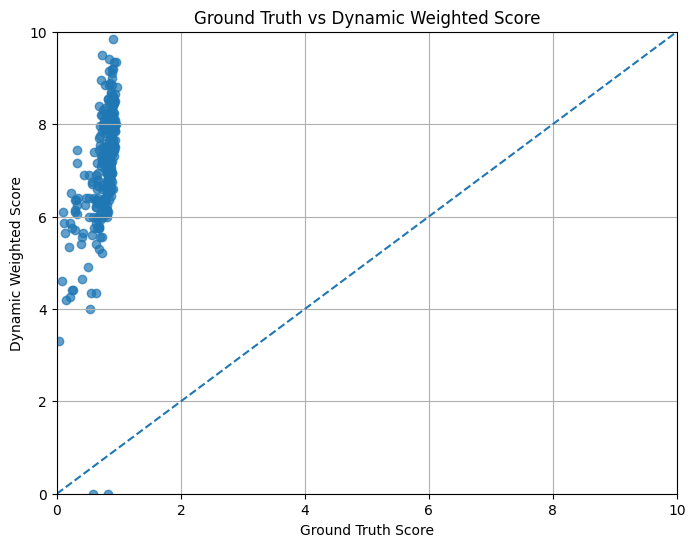

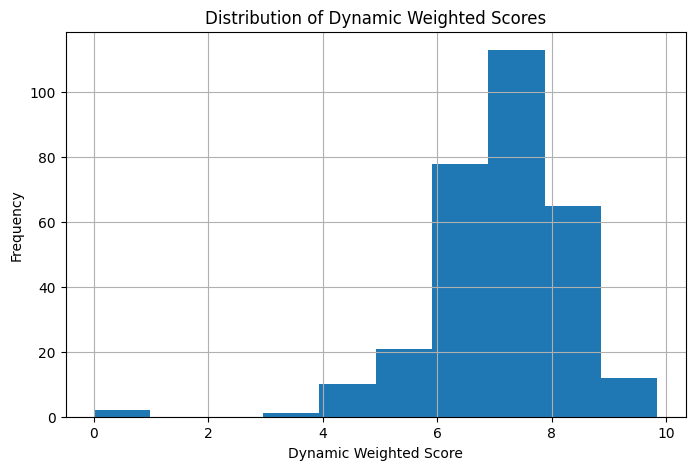

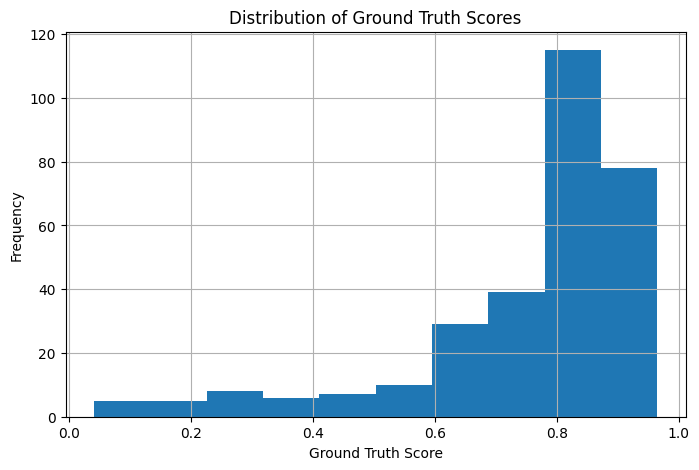

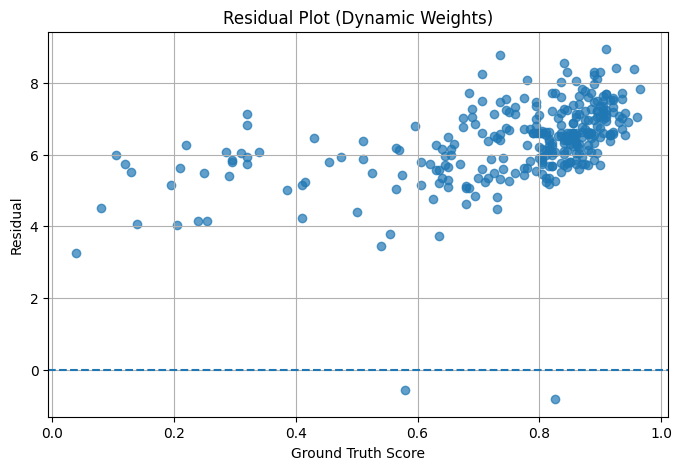

In [7]:
# ============================================================
# DYNAMIC WEIGHT VISUALIZATION
# ============================================================

print("="*80)
print("DYNAMIC WEIGHT VISUALIZATION")
print("="*80)

import matplotlib.pyplot as plt

plot_df = evaluation_df.copy()

# ============================================================
# Scatter Plot
# ============================================================

plt.figure(figsize=(8,6))

plt.scatter(

    plot_df["ground_truth_score"],

    plot_df["predicted_score"],

    alpha=0.7

)

plt.plot(

    [0,10],

    [0,10],

    linestyle="--"

)

plt.xlabel("Ground Truth Score")

plt.ylabel("Dynamic Weighted Score")

plt.title("Ground Truth vs Dynamic Weighted Score")

plt.xlim(0,10)

plt.ylim(0,10)

plt.grid(True)

plt.show()

# ============================================================
# Dynamic Score Distribution
# ============================================================

plt.figure(figsize=(8,5))

plt.hist(

    plot_df["predicted_score"],

    bins=10

)

plt.xlabel("Dynamic Weighted Score")

plt.ylabel("Frequency")

plt.title("Distribution of Dynamic Weighted Scores")

plt.grid(True)

plt.show()

# ============================================================
# Ground Truth Distribution
# ============================================================

plt.figure(figsize=(8,5))

plt.hist(

    plot_df["ground_truth_score"],

    bins=10

)

plt.xlabel("Ground Truth Score")

plt.ylabel("Frequency")

plt.title("Distribution of Ground Truth Scores")

plt.grid(True)

plt.show()

# ============================================================
# Residual Plot
# ============================================================

residuals = (

    plot_df["predicted_score"]

    -

    plot_df["ground_truth_score"]

)

plt.figure(figsize=(8,5))

plt.scatter(

    plot_df["ground_truth_score"],

    residuals,

    alpha=0.7

)

plt.axhline(

    y=0,

    linestyle="--"

)

plt.xlabel("Ground Truth Score")

plt.ylabel("Residual")

plt.title("Residual Plot (Dynamic Weights)")

plt.grid(True)

plt.show()


